# Korpus-Diagnose & Qualitätsanalyse

Dieses Notebook konsolidiert die Analysen der verschiedenen Hilfsskripte. Es lädt die Master-CSV des Korpus (`data/analysis/corpus_master.csv`) und bietet eine interaktive Auswertung der Metriken, Längenverteilungen und Qualitätsmerkmale.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Datensatz laden

Wir laden die Master-CSV-Datei, die alle vorberechneten Textpaare und Metriken enthält.

In [2]:
CSV_PATH = "../../data/analysis/corpus_master.csv"

if not os.path.exists(CSV_PATH):
    # Fallback falls vom Repository-Root ausgeführt
    CSV_PATH = "data/analysis/corpus_master.csv"

df = pd.read_csv(CSV_PATH)
print(f"Erfolgreich {len(df)} Artikelpaare geladen.")
df.head(2)

Erfolgreich 1466 Artikelpaare geladen.


,source,as_url,ls_url,as_text,ls_text,semantic_similarity_8192,ner_recall_as_ls,ner_recall_ls_as,as_ent_count,ls_ent_count,...,as_flesch,as_wiener,as_lix,ls_flesch,ls_wiener,ls_lix,as_ttr,as_mattr,ls_ttr,ls_mattr
0,apotheken,https://www.apotheken-umschau.de/krankheiten-s...,https://www.apotheken-umschau.de/einfache-spra...,Was ist die Ursache für Weitsichtigkeit? Sympt...,Was ist Weitsichtigkeit? Weitsichtigkeit ist e...,0.831560,0.000000,1.000000,22,0,...,43.863329,10.357936,51.077324,65.309691,6.508046,37.466485,0.335905,0.764046,0.295903,0.670230
1,apotheken,https://www.apotheken-umschau.de/medikamente/h...,https://www.apotheken-umschau.de/einfache-spra...,Was ist Baldrian? Gegen was hilft Baldrian? Gi...,Was ist Baldrian? Baldrian ist eine Heilpflanz...,0.955094,0.837838,0.837838,37,37,...,38.182303,12.341956,54.347548,49.263063,9.968115,47.123894,0.452982,0.807388,0.387097,0.725231


## 2. Korpus-Übersicht (Statistiken pro Quelle)

Wir gruppieren das Korpus nach Quelle, um die Artikelanzahl, die Tokenanzahlen und die Kompressions-Ratios zu berechnen.

In [3]:
summary = df.groupby("source").agg(
    pairs=("as_text", "count"),
    total_as_tokens=("as_tokens", "sum"),
    total_ls_tokens=("ls_tokens", "sum"),
    avg_as_tokens=("as_tokens", "mean"),
    avg_ls_tokens=("ls_tokens", "mean"),
    avg_similarity=("semantic_similarity_8192", "mean")
)

summary["ratio_ls_as"] = summary["total_ls_tokens"] / summary["total_as_tokens"]

# Gesamtsummen-Zeile hinzufügen
total_row = pd.Series({
    "pairs": len(df),
    "total_as_tokens": df["as_tokens"].sum(),
    "total_ls_tokens": df["ls_tokens"].sum(),
    "avg_as_tokens": df["as_tokens"].mean(),
    "avg_ls_tokens": df["ls_tokens"].mean(),
    "avg_similarity": df["semantic_similarity_8192"].mean(),
    "ratio_ls_as": df["ls_tokens"].sum() / df["as_tokens"].sum()
}, name="TOTAL")

summary = pd.concat([summary, pd.DataFrame([total_row])])
summary.round(3)

,pairs,total_as_tokens,total_ls_tokens,avg_as_tokens,avg_ls_tokens,avg_similarity,ratio_ls_as
apotheken,157.0,198527.0,104645.0,1264.503,666.529,0.846,0.527
behindertenbeauftragter,51.0,20173.0,19367.0,395.549,379.745,0.859,0.960
brandeins,18.0,3404.0,3542.0,189.111,196.778,0.705,1.041
hamburg,51.0,23511.0,24052.0,461.000,471.608,0.816,1.023
hannover,796.0,388978.0,440503.0,488.666,553.396,0.836,1.132
koeln,38.0,20029.0,29853.0,527.079,785.605,0.828,1.490
main_taunus,34.0,5353.0,5558.0,157.441,163.471,0.817,1.038
mdr,227.0,80186.0,46792.0,353.242,206.132,0.793,0.584
sozialpolitik,14.0,11315.0,4912.0,808.214,350.857,0.788,0.434
stuttgart,39.0,38573.0,22384.0,989.051,573.949,0.833,0.580


## 3. SBERT Kontext-Längenanalyse (Coverage)

Hier prüfen wir, wie viele Artikel die typischen Token-Grenzen (z. B. 512 Tokens) überschreiten.

In [4]:
MAX_SBERT_LENGTH = 512
total = len(df)

print(f"=== SBERT Coverage Analyse (Limit: {MAX_SBERT_LENGTH} Tokens) ===\n")

for col, label in [('as_tokens', 'Alltagssprache (AS)'), ('ls_tokens', 'Leichte Sprache (LS)')]:
    full_coverage = sum(df[col] <= MAX_SBERT_LENGTH)
    truncated = total - full_coverage
    
    percent_full = (full_coverage / total) * 100
    percent_trunc = (truncated / total) * 100
    
    print(f"{label}:")
    print(f"  Vollständig erfasst: {full_coverage:4d} Artikel ({percent_full:5.1f}%)")
    print(f"  Abgeschnitten:       {truncated:4d} Artikel ({percent_trunc:5.1f}%)")
    
    truncated_df = df[df[col] > MAX_SBERT_LENGTH]
    if not truncated_df.empty:
        avg_total = truncated_df[col].mean()
        print(f"  Ø Länge bei Kürzung: {avg_total:5.1f} Tokens")
    print("-" * 45)

=== SBERT Coverage Analyse (Limit: 512 Tokens) ===

Alltagssprache (AS):
  Vollständig erfasst:  952 Artikel ( 64.9%)
  Abgeschnitten:        514 Artikel ( 35.1%)
  Ø Länge bei Kürzung: 1081.5 Tokens
---------------------------------------------
Leichte Sprache (LS):
  Vollständig erfasst:  949 Artikel ( 64.7%)
  Abgeschnitten:        517 Artikel ( 35.3%)
  Ø Länge bei Kürzung: 884.1 Tokens
---------------------------------------------


## 4. Visualisierung der Metriken

### A. Semantische Ähnlichkeit
Verteilung der semantischen Ähnlichkeit (SBERT Jina 8192) über alle Quellen hinweg.

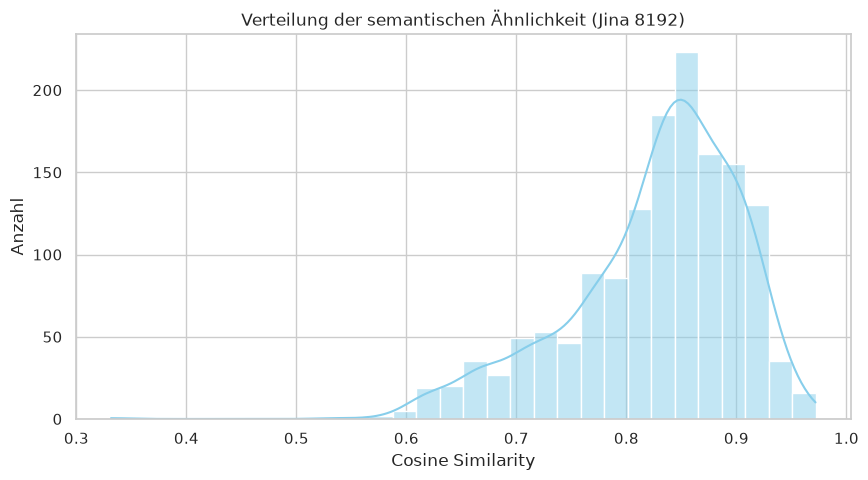

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df["semantic_similarity_8192"], kde=True, bins=30, color="skyblue")
plt.title("Verteilung der semantischen Ähnlichkeit (Jina 8192)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Anzahl")
plt.show()

### B. Lesbarkeit im Vergleich (AS vs. LS)
Vergleich der Flesch-Reading-Ease-Scores zwischen Alltagssprache (AS) und Leichter Sprache (LS).

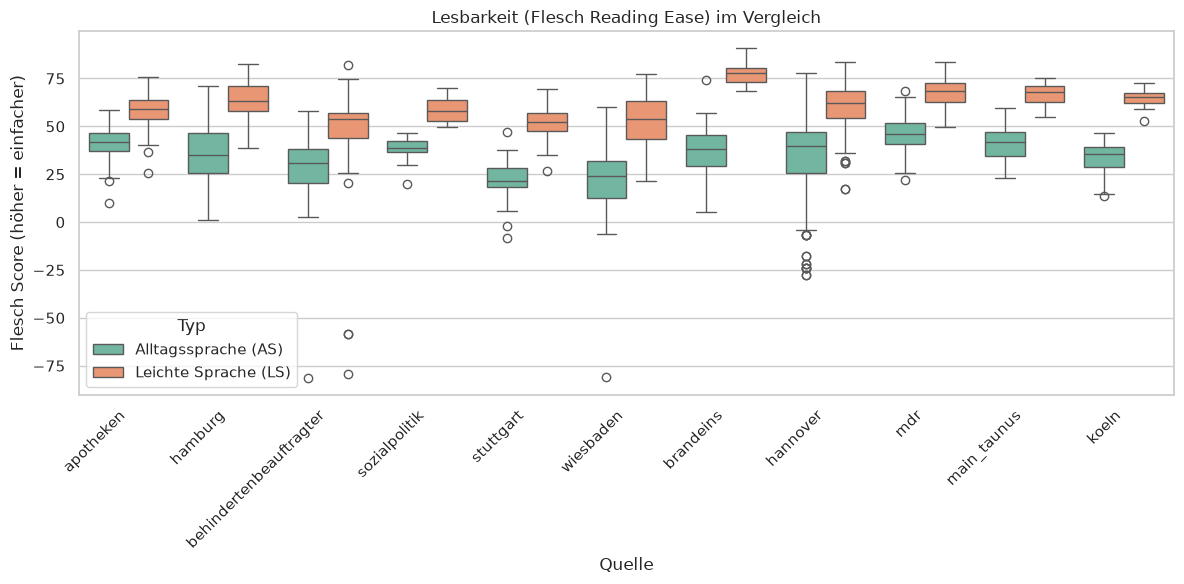

In [6]:
# Daten für den Vergleich vorbereiten
readability_df = df[["source", "as_flesch", "ls_flesch"]].melt(
    id_vars="source", 
    value_vars=["as_flesch", "ls_flesch"],
    var_name="Typ",
    value_name="Flesch Score"
)
readability_df["Typ"] = readability_df["Typ"].map({"as_flesch": "Alltagssprache (AS)", "ls_flesch": "Leichte Sprache (LS)"})

plt.figure(figsize=(12, 6))
sns.boxplot(data=readability_df, x="source", y="Flesch Score", hue="Typ", palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Lesbarkeit (Flesch Reading Ease) im Vergleich")
plt.xlabel("Quelle")
plt.ylabel("Flesch Score (höher = einfacher)")
plt.tight_layout()
plt.show()

### C. Lexikalische Vielfalt (MATTR)
Wie unterscheidet sich der Wortschatz-Reichtum (MATTR) zwischen AS und LS?

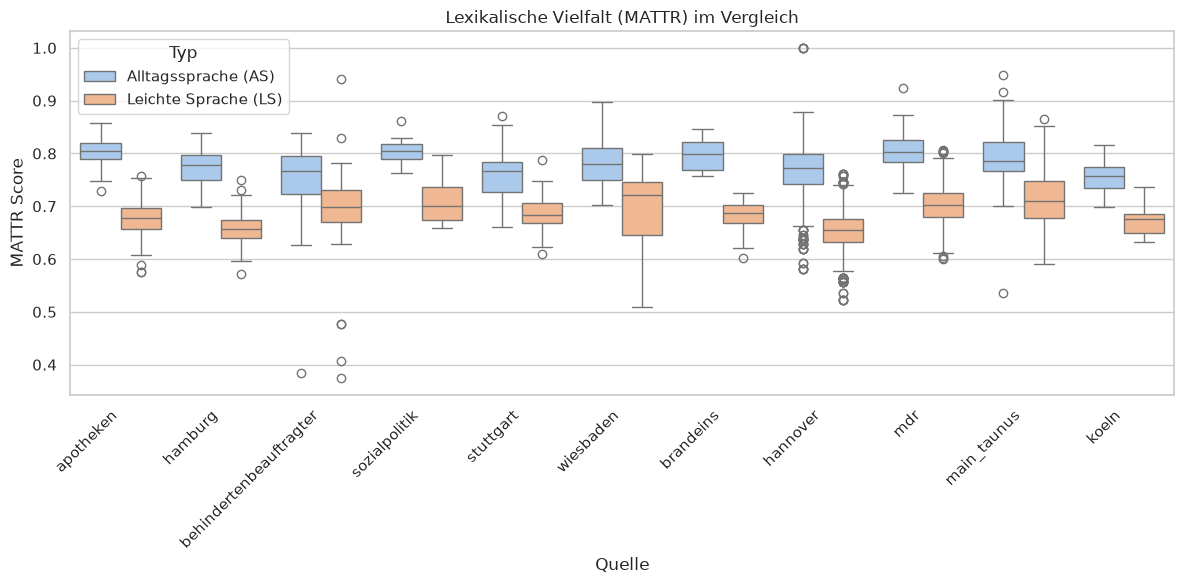

In [7]:
mattr_df = df[["source", "as_mattr", "ls_mattr"]].melt(
    id_vars="source",
    value_vars=["as_mattr", "ls_mattr"],
    var_name="Typ",
    value_name="MATTR (Window=50)"
)
mattr_df["Typ"] = mattr_df["Typ"].map({"as_mattr": "Alltagssprache (AS)", "ls_mattr": "Leichte Sprache (LS)"})

plt.figure(figsize=(12, 6))
sns.boxplot(data=mattr_df, x="source", y="MATTR (Window=50)", hue="Typ", palette="pastel")
plt.xticks(rotation=45, ha="right")
plt.title("Lexikalische Vielfalt (MATTR) im Vergleich")
plt.xlabel("Quelle")
plt.ylabel("MATTR Score")
plt.tight_layout()
plt.show()